In [1]:
!pip install pennylane pennylane-lightning torch torchvision scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.2 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving y_train.npy to y_train.npy
Saving X_test_pca.npy to X_test_pca.npy
Saving y_test.npy to y_test.npy
Saving X_train_pca.npy to X_train_pca.npy


In [3]:
import numpy as np
import torch

X_train = np.load("X_train_pca.npy")
X_test = np.load("X_test_pca.npy")

y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [4]:
import pennylane as qml
import torch.nn as nn
import torch.optim as optim

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score
)

In [5]:
import pennylane as qml
import torch
import torch.nn as nn

# Quantum Device
n_qubits = 4

dev = qml.device(
    "lightning.qubit",
    wires=n_qubits
)

# AVQFM Quantum Circuit
@qml.qnode(dev, interface="torch")
def avqfm_circuit(inputs, weights):

    # Feature Encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Adaptive Depth Allocation

    # Qubit 0 -> Depth 1
    qml.RY(weights[0], wires=0)

    # Qubit 1 -> Depth 2
    qml.RY(weights[1], wires=1)
    qml.RY(weights[2], wires=1)

    # Qubit 2 -> Depth 3
    qml.RY(weights[3], wires=2)
    qml.RY(weights[4], wires=2)
    qml.RY(weights[5], wires=2)

    # Qubit 3 -> Depth 4
    qml.RY(weights[6], wires=3)
    qml.RY(weights[7], wires=3)
    qml.RY(weights[8], wires=3)
    qml.RY(weights[9], wires=3)

    # Entanglement
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(n_qubits)
    ]


# AVQFM Model
class AVQFM(nn.Module):

    def __init__(self):

        super().__init__()

        self.q_weights = nn.Parameter(
            0.01 * torch.randn(10)
        )

        self.fc = nn.Linear(
            4,
            1
        )

    def forward(self, x):

        outputs = []

        for sample in x:

            q_out = avqfm_circuit(
                sample,
                self.q_weights
            )

            outputs.append(
                torch.stack(q_out)
            )

        outputs = torch.stack(outputs)

        out = self.fc(outputs)

        return torch.sigmoid(
            out.squeeze()
        )

print("AVQFM loaded successfully")

AVQFM loaded successfully


In [6]:
import torch
import torch.nn as nn

class AVQFM_Gated(nn.Module):

    def __init__(self):

        super().__init__()

        self.q_weights = nn.Parameter(
            0.01 * torch.randn(10)
        )

        # Learnable feature gates
        self.feature_gates = nn.Parameter(
            torch.ones(4)
        )

        self.fc = nn.Linear(
            4,
            1
        )

    def forward(self, x):

        outputs = []

        for sample in x:

            q_out = avqfm_circuit(
                sample,
                self.q_weights
            )

            outputs.append(
                torch.stack(q_out)
            )

        outputs = torch.stack(outputs)

        # Apply gates
        gated_outputs = (
            outputs *
            torch.sigmoid(
                self.feature_gates
            )
        )

        out = self.fc(
            gated_outputs
        )

        return torch.sigmoid(
            out.squeeze()
        )

In [7]:
model = AVQFM_Gated()

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

print(model)

AVQFM_Gated(
  (fc): Linear(in_features=4, out_features=1, bias=True)
)


In [8]:
preds = model(
    X_train[:5]
)

print(preds)

tensor([0.6197, 0.6310, 0.6340, 0.6269, 0.6218], grad_fn=<SigmoidBackward0>)


In [9]:
epochs = 30

loss_history = []
gradient_variance_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    preds = model(X_train)

    loss = criterion(
        preds,
        y_train
    )

    loss.backward()

    grad_values = []

    for p in model.parameters():

        grad_values.extend(
            p.grad.detach()
            .cpu()
            .numpy()
            .flatten()
        )

    grad_var = np.var(
        grad_values
    )

    gradient_variance_history.append(
        grad_var
    )

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss.item():.4f} | "
        f"GradVar={grad_var:.8f}"
    )

Epoch 01 | Loss=0.6736 | GradVar=0.00092659
Epoch 02 | Loss=0.6708 | GradVar=0.00092756
Epoch 03 | Loss=0.6680 | GradVar=0.00092895
Epoch 04 | Loss=0.6653 | GradVar=0.00093108
Epoch 05 | Loss=0.6625 | GradVar=0.00093368
Epoch 06 | Loss=0.6598 | GradVar=0.00093614
Epoch 07 | Loss=0.6570 | GradVar=0.00093828
Epoch 08 | Loss=0.6542 | GradVar=0.00094002
Epoch 09 | Loss=0.6514 | GradVar=0.00094131
Epoch 10 | Loss=0.6485 | GradVar=0.00094208
Epoch 11 | Loss=0.6456 | GradVar=0.00094226
Epoch 12 | Loss=0.6428 | GradVar=0.00094178
Epoch 13 | Loss=0.6399 | GradVar=0.00094060
Epoch 14 | Loss=0.6370 | GradVar=0.00093868
Epoch 15 | Loss=0.6341 | GradVar=0.00093599
Epoch 16 | Loss=0.6312 | GradVar=0.00093257
Epoch 17 | Loss=0.6284 | GradVar=0.00092844
Epoch 18 | Loss=0.6256 | GradVar=0.00092370
Epoch 19 | Loss=0.6228 | GradVar=0.00091848
Epoch 20 | Loss=0.6200 | GradVar=0.00091293
Epoch 21 | Loss=0.6173 | GradVar=0.00090726
Epoch 22 | Loss=0.6146 | GradVar=0.00090166
Epoch 23 | Loss=0.6119 | GradVar

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

with torch.no_grad():

    probs = model(X_test)

preds = (probs > 0.5).int()

acc = accuracy_score(
    y_test.numpy(),
    preds.numpy()
)

f1 = f1_score(
    y_test.numpy(),
    preds.numpy()
)

print("Accuracy =", acc)
print("F1 Score =", f1)

Accuracy = 0.644
F1 Score = 0.760752688172043


In [11]:
print(
    "Learned Gates:"
)

print(
    torch.sigmoid(
        model.feature_gates
    )
)

Learned Gates:
tensor([0.7881, 0.7063, 0.6851, 0.7875], grad_fn=<SigmoidBackward0>)


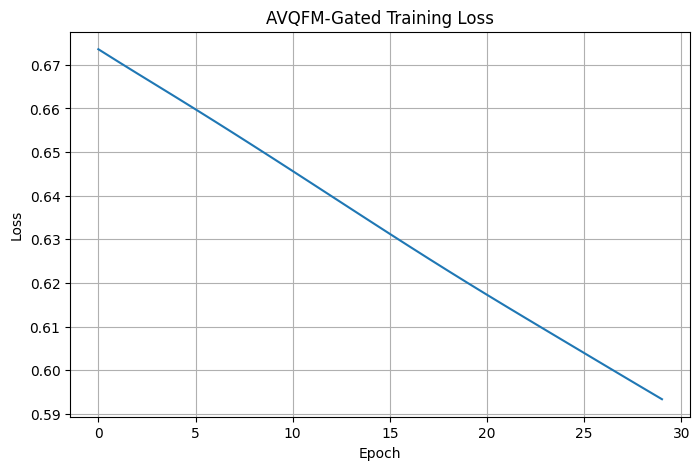

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "AVQFM-Gated Training Loss"
)

plt.grid(True)

plt.savefig(
    "Fig_E5_Training_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

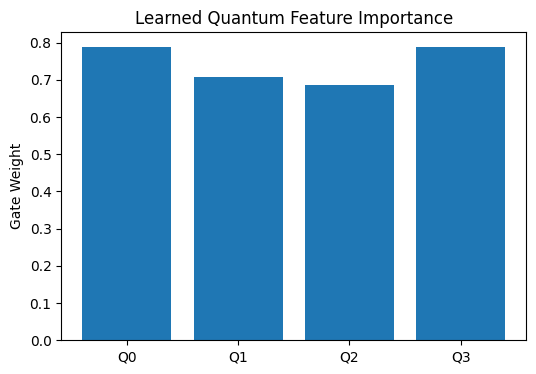

In [13]:
gates = (
    torch.sigmoid(
        model.feature_gates
    )
    .detach()
    .numpy()
)

plt.figure(figsize=(6,4))

plt.bar(
    ["Q0","Q1","Q2","Q3"],
    gates
)

plt.ylabel(
    "Gate Weight"
)

plt.title(
    "Learned Quantum Feature Importance"
)

plt.savefig(
    "Fig_E5_Feature_Gates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
seeds = [1, 7, 21, 42, 100]

print("Seeds:", seeds)

Seeds: [1, 7, 21, 42, 100]


In [ ]:
results = []

for seed in seeds:

    print(f"\nRunning Seed {seed}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = AVQFM()

    criterion = nn.BCELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.01
    )

    epochs = 30

    for epoch in range(epochs):

        optimizer.zero_grad()

        preds = model(X_train)

        loss = criterion(
            preds,
            y_train
        )

        loss.backward()

        optimizer.step()

    # Evaluation
    with torch.no_grad():

        probs = model(X_test)

    preds = (probs > 0.5).int()

    acc = accuracy_score(
        y_test.numpy(),
        preds.numpy()
    )

    f1 = f1_score(
        y_test.numpy(),
        preds.numpy()
    )

    results.append(
        [seed, acc, f1]
    )

    print(
        f"Accuracy={acc:.4f} | "
        f"F1={f1:.4f}"
    )


Running Seed 1
Accuracy=0.6740 | F1=0.7739

Running Seed 7
Accuracy=0.6240 | F1=0.7507

Running Seed 21
Accuracy=0.6820 | F1=0.6901

Running Seed 42
Accuracy=0.7720 | F1=0.8288

Running Seed 100
Accuracy=0.7580 | F1=0.8052


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Seed",
        "Accuracy",
        "F1"
    ]
)

results_df

,Seed,Accuracy,F1
0,1,0.674,0.773925
1,7,0.624,0.750663
2,21,0.682,0.690058
3,42,0.772,0.828829
4,100,0.758,0.805153


In [ ]:
print(
    "Mean Accuracy:",
    results_df["Accuracy"].mean()
)

print(
    "Std Accuracy:",
    results_df["Accuracy"].std()
)

print(
    "Mean F1:",
    results_df["F1"].mean()
)

print(
    "Std F1:",
    results_df["F1"].std()
)

Mean Accuracy: 0.702
Std Accuracy: 0.06185466837676846
Mean F1: 0.7697257042845362
Std F1: 0.053563407580659694


In [ ]:
results_df.to_csv(
    "AVQFM_MultiSeed_Results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [ ]:
from google.colab import files

files.download(
    "AVQFM_MultiSeed_Results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Mean Accuracy: 0.7020
Std Accuracy: 0.0619

Mean F1 Score: 0.7697
Std F1 Score: 0.0536

Conclusion:
The initial AVQFM architecture achieved promising
peak performance but exhibited significant
variability across random initializations,
indicating the need for more robust adaptive
feature allocation mechanisms.